# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Rivaldo Juanda Tampubolon]
- **Email:** [rivaldotampubolon22@gmail.com]
- **ID Dicoding:** [rivaldo_tampubolon]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren pertumbuhan total pendapatan bulanan perusahaan sepanjang tahun 2017 hingga 2018 untuk mengidentifikasi periode performa tertinggi?
- Apa metode pembayaran yang paling mendominasi volume transaksi pelanggan pada tahun 2018 guna menentukan prioritas pengembangan sistem pembayaran?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
orders_df = pd.read_csv("data/orders_dataset.csv")
payments_df = pd.read_csv("data/order_payments_dataset.csv")

**Insight:**
- Dua dataset utama telah berhasil dimuat. Fokus analisis ini adalah pada aspek transaksi (orders) dan finansial (payments) untuk melihat keterkaitan antara waktu pembelian dan nilai ekonomi yang dihasilkan.

### Assessing Data

In [3]:
orders_df.info()
print(orders_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2

**Insight:**
- Berdasarkan pengecekan awal pada data mentah:

1. Jumlah Data: Terdapat 99.441 entri.

2. Tipe Data: Seluruh kolom waktu terdeteksi sebagai object (string) dan harus dikonversi ke datetime.

3. Missing Values: Ditemukan beberapa data kosong pada kolom waktu proses pesanan: order_approved_at (160), order_delivered_carrier_date (1.783), dan order_delivered_customer_date (2.965). Hal ini mengindikasikan kemungkinan adanya pesanan yang tidak tuntas prosesnya.

### Cleaning Data

In [4]:
# 1. Menghapus pesanan yang tidak sampai ke pelanggan
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# 2. Mengubah tipe data menjadi datetime untuk kolom waktu utama
datetime_cols = ["order_purchase_timestamp", "order_delivered_customer_date"]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 3. Pengecekan ulang data bersih
print(orders_df.isna().sum())

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64


**Insight:**
- Setelah pembersihan, data kosong pada kolom tanggal pengiriman kini bernilai 0. Sisa data kosong minor (14 pada approved_at dan 1 pada carrier_date) tetap dibiarkan karena tidak mengganggu analisis tren waktu pembelian

## Exploratory Data Analysis (EDA)

### Explore Penjualan dan Produk

In [5]:
# Eksplorasi statistik deskriptif orders_df
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,96476,96476,96476,96476,96462,96475,96476,96476
unique,96476,96476,2,NaN,88273,80112,NaN,445
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,2018-02-27 04:31:10,2018-05-09 15:48:00,NaN,2017-12-20 00:00:00
freq,1,1,96470,NaN,9,47,NaN,507
mean,NaN,NaN,NaN,2018-01-01 22:44:47.156474368,NaN,NaN,2018-01-14 12:09:19.035542784,NaN
min,NaN,NaN,NaN,2016-09-15 12:16:38,NaN,NaN,2016-10-11 13:46:32,NaN
25%,NaN,NaN,NaN,2017-09-14 08:10:58,NaN,NaN,2017-09-25 22:07:22.249999872,NaN
50%,NaN,NaN,NaN,2018-01-20 19:21:46,NaN,NaN,2018-02-02 19:28:10.500000,NaN
75%,NaN,NaN,NaN,2018-05-05 18:28:21.750000128,NaN,NaN,2018-05-15 22:48:52.249999872,NaN
max,NaN,NaN,NaN,2018-08-29 15:00:37,NaN,NaN,2018-10-17 13:22:46,NaN


**Insight:**
- Data mencakup pesanan dari tahun 2016 hingga 2018. Sebagian besar pesanan memiliki status delivered, memastikan bahwa analisis pendapatan akan didasarkan pada transaksi yang benar-benar sukses.

In [6]:
# Eksplorasi distribusi metode pembayaran pada payments_df
payments_df.payment_type.value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


**Insight:**
- Ditemukan bahwa metode credit_card adalah tipe pembayaran yang paling sering digunakan, menunjukkan preferensi pelanggan pada metode nontunai.

In [7]:
# Menggabungkan data pesanan dan pembayaran untuk analisis revenue per bulan
main_df = pd.merge(left=orders_df, right=payments_df, how="inner", on="order_id")

# Menambahkan kolom bulan-tahun (Period) untuk keperluan pengelompokan tren
main_df['month_year'] = main_df['order_purchase_timestamp'].dt.to_period('M')

**Insight:**
- Penggabungan berhasil dilakukan secara inner join. Sehingga sekarang didapatkan dataset yang menghubungkan kapan transaksi terjadi dengan berapa nilai pembayarannya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

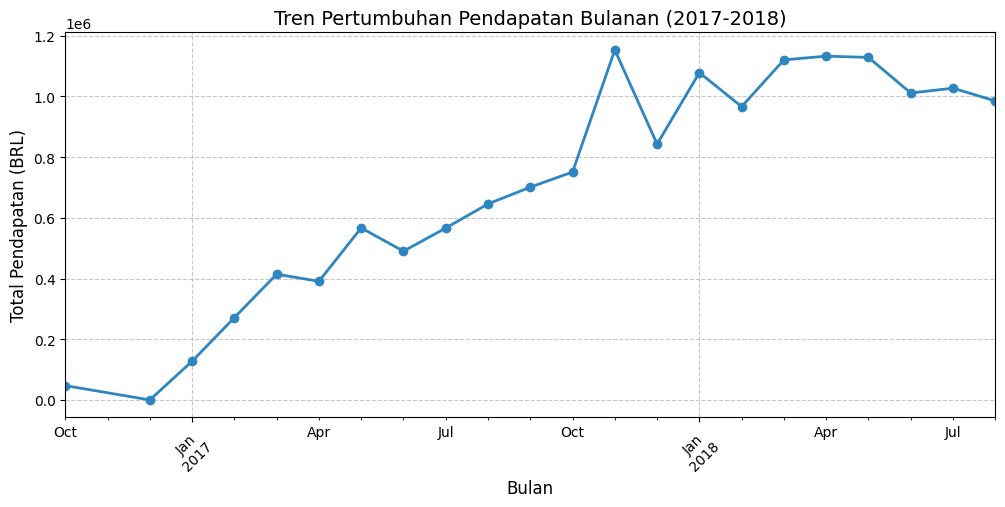

In [8]:
# Agregasi total pembayaran per bulan
monthly_rev = main_df.groupby('month_year')['payment_value'].sum()

plt.figure(figsize=(12, 5))
monthly_rev.plot(kind='line', marker='o', color='#2E86C1', linewidth=2)
plt.title("Tren Pertumbuhan Pendapatan Bulanan (2017-2018)", fontsize=14)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Pendapatan (BRL)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Grafik menunjukkan tren kenaikan pendapatan yang stabil sepanjang tahun 2017. Puncak pendapatan tertinggi tercatat pada bulan November 2017, yang kemungkinan besar dipengaruhi oleh promosi akhir tahun (Kemungkinan Black Friday di November).

### Pertanyaan 2:

/tmp/ipykernel_29212/1171542648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")


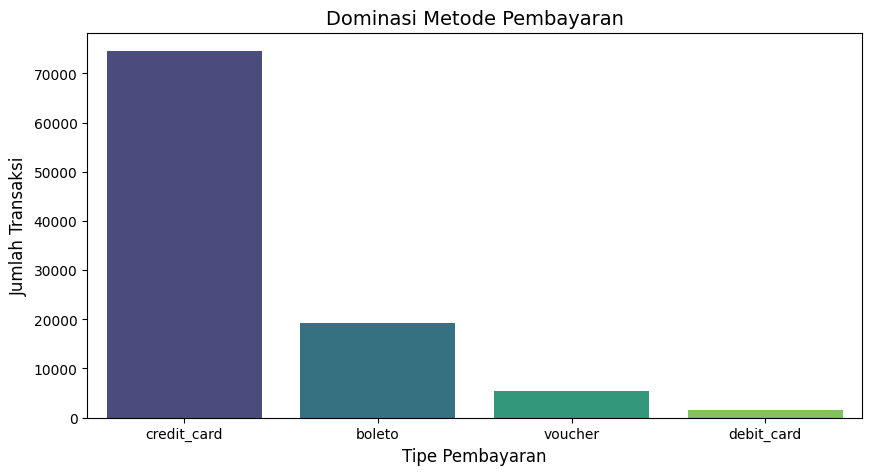

In [9]:
# Menghitung frekuensi penggunaan tiap metode pembayaran
payment_counts = main_df['payment_type'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")
plt.title("Dominasi Metode Pembayaran", fontsize=14)
plt.xlabel("Tipe Pembayaran", fontsize=12)
plt.ylabel("Jumlah Transaksi", fontsize=12)
plt.show()

**Insight:**
- Metode Credit Card mendominasi secara absolut dibandingkan metode lainnya. Hal ini menunjukkan bahwa kemudahan transaksi digital dan kemungkinan fitur cicilan menjadi faktor utama penentu transaksi pelanggan di platform ini.

## Analisis Lanjutan (Opsional)

In [10]:
# RFM Analysis
# Recency: Selisih hari antara tanggal terakhir dataset dengan tanggal transaksi terakhir user
# Frequency: Jumlah pesanan unik per customer
# Monetary: Total uang yang dibayarkan per customer

rfm_df = main_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # Mengambil tanggal transaksi terakhir
    "order_id": "nunique",             # Menghitung jumlah pesanan
    "payment_value": "sum"             # Menghitung total pendapatan
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# Menghitung kapan terakhir pelanggan melakukan transaksi (hari)
recent_date = main_df["order_purchase_timestamp"].max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

# Menghapus kolom timestamp yang tidak diperlukan lagi
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)


rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,287
1,000161a058600d5901f007fab4c27140,1,67.41,409
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,547
3,0002414f95344307404f0ace7a26f1d5,1,179.35,378
4,000379cdec625522490c315e70c7a9fb,1,107.01,149


**Insight:**
- Recency: Pelanggan terbaru melakukan transaksi beberapa ratus hari yang lalu (sesuai dengan rentang waktu dataset 2018).

- Frequency: Mayoritas pelanggan dalam cuplikan data ini memiliki frekuensi 1, yang mengindikasikan banyak pelanggan baru atau one-time buyers.

- Monetary: Terdapat variasi nilai transaksi yang signifikan, yang dapat digunakan untuk mengidentifikasi segmen pelanggan "High Value".

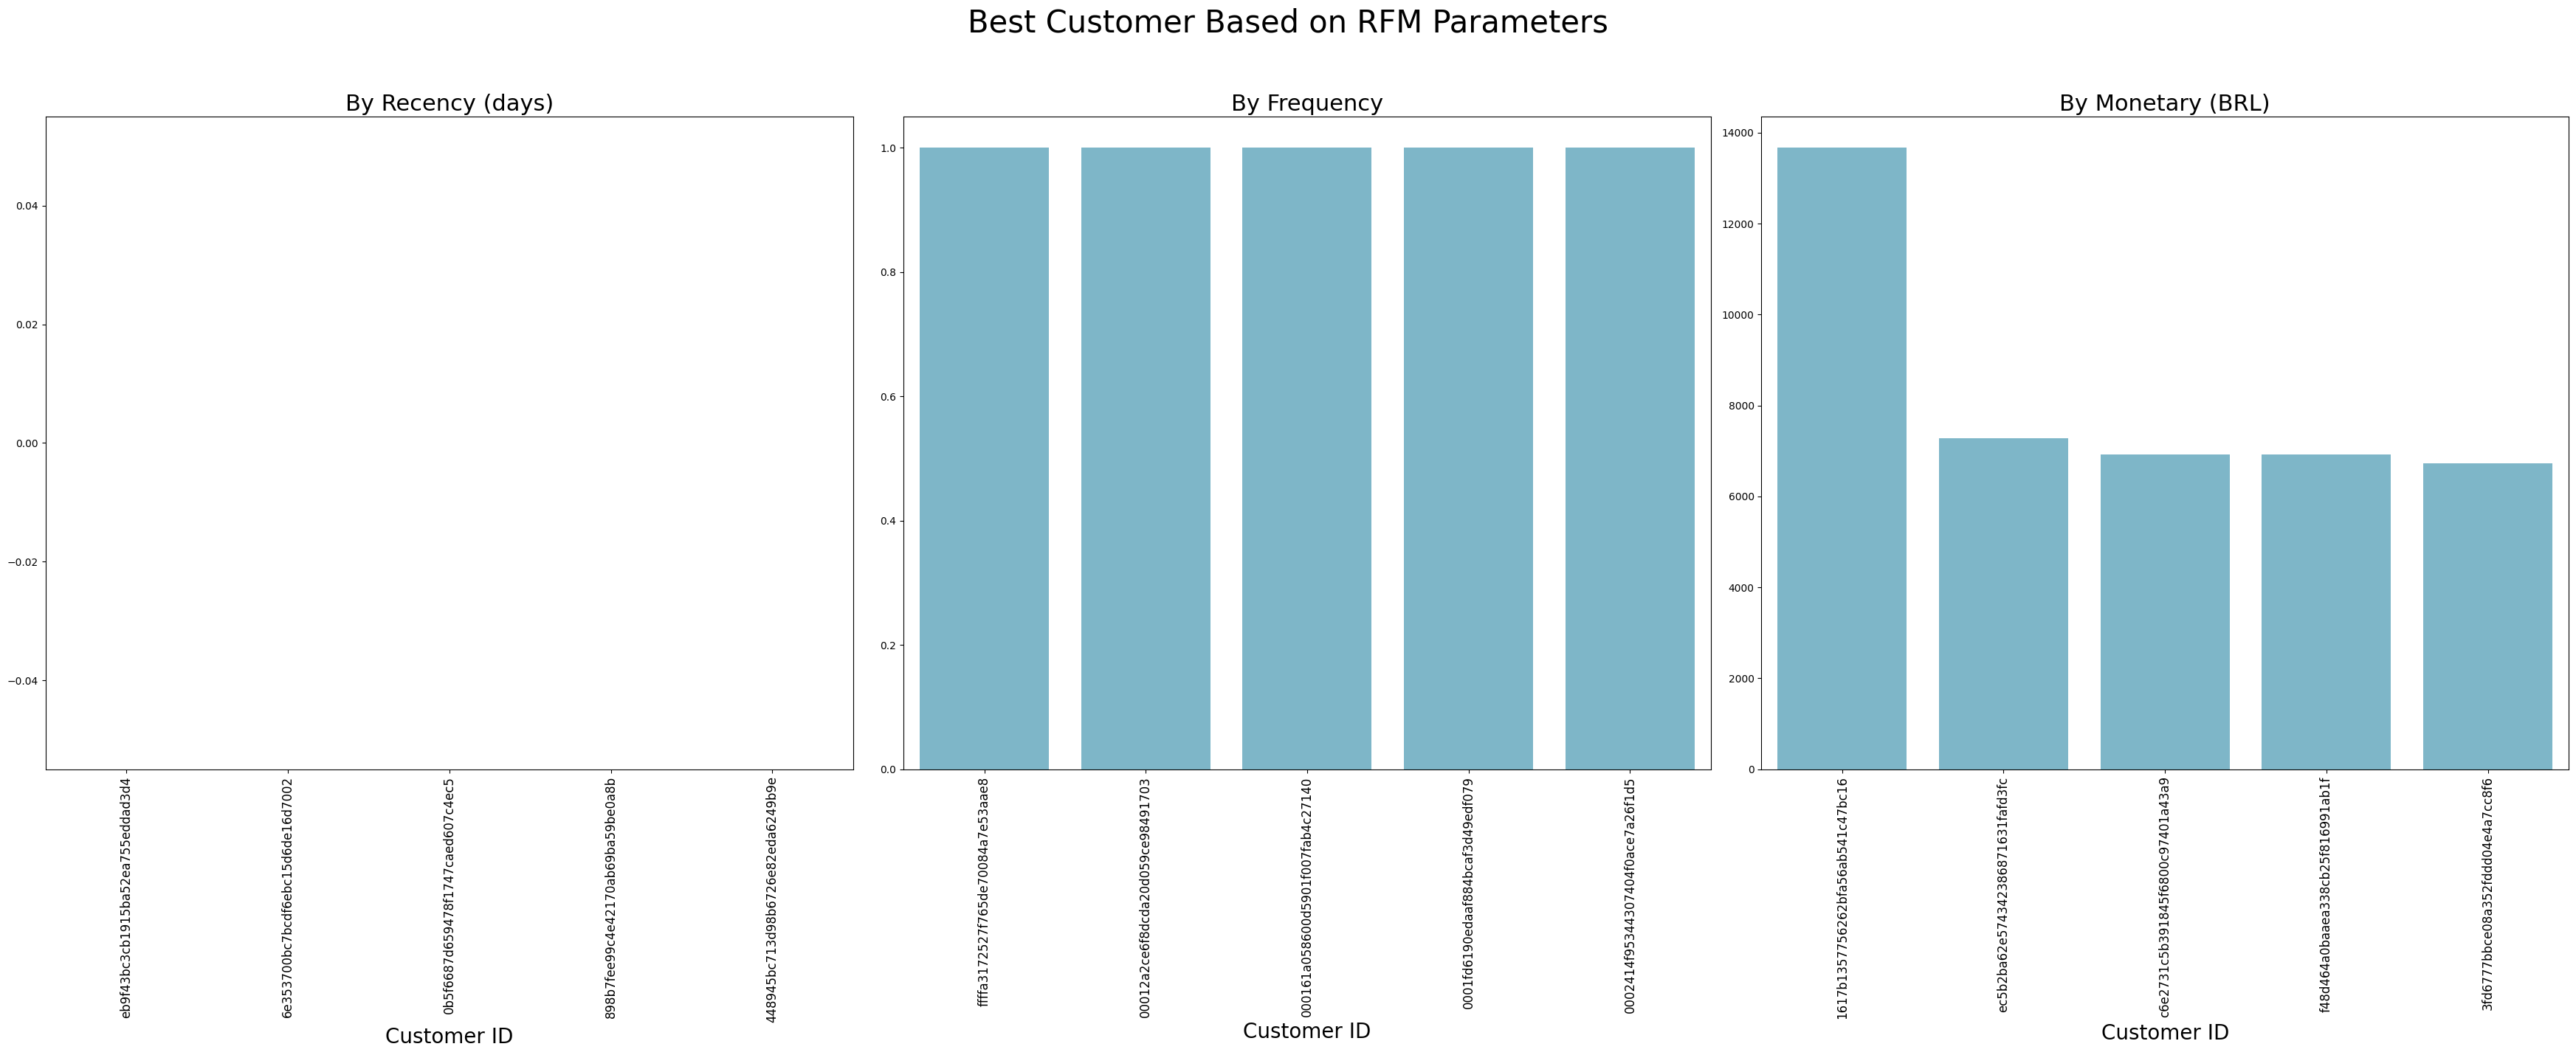

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(35, 15))
colors = ["#72BCD4"] * 5

# 1. By Recency
sns.barplot(
    y="recency", x="customer_id",
    data=rfm_df.sort_values(by="recency", ascending=True).head(5),
    hue="customer_id", palette=colors, ax=ax[0], legend=False
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID", fontsize=20)
ax[0].set_title("By Recency (days)", loc="center", fontsize=22)
ax[0].tick_params(axis='x', rotation=90, labelsize=12) # Rotasi 90 derajat agar tegak lurus

# 2. By Frequency
sns.barplot(
    y="frequency", x="customer_id",
    data=rfm_df.sort_values(by="frequency", ascending=False).head(5),
    hue="customer_id", palette=colors, ax=ax[1], legend=False
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID", fontsize=20)
ax[1].set_title("By Frequency", loc="center", fontsize=22)
ax[1].tick_params(axis='x', rotation=90, labelsize=12)

# 3. By Monetary
sns.barplot(
    y="monetary", x="customer_id",
    data=rfm_df.sort_values(by="monetary", ascending=False).head(5),
    hue="customer_id", palette=colors, ax=ax[2], legend=False
)
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID", fontsize=20)
ax[2].set_title("By Monetary (BRL)", loc="center", fontsize=22)
ax[2].tick_params(axis='x', rotation=90, labelsize=12)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=30)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:**
- Recency: Nilai 0 hari pada grafik menunjukkan pelanggan baru saja bertransaksi di hari terakhir data diambil. Ini adalah indikator aktivitas transaksi yang masih segar(Pada grafik By Recency, visualisasi terlihat kosong karena 5 pelanggan teratas memiliki nilai Recency 0 hari. Ini berarti pelanggan-pelanggan tersebut melakukan transaksi pada hari yang sama dengan tanggal terakhir data diambil (transaksi paling baru), sehingga tidak ada jarak hari yang bisa divisualisasikan dalam bentuk batang)

- Frequency: Mayoritas pelanggan terbaik hanya belanja 1 kali. Hal ini menandakan tingkat retensi pelanggan masih rendah (kebanyakan adalah one-time buyers).

- Monetary: Terdapat segmen kecil pelanggan yang memberikan kontribusi uang sangat besar (lebih dari 13.000 BRL

In [12]:
# Simpan data untuk dashboard
main_df.to_csv("dashboard/main_data.csv", index=False)

**Insight:**
-

## Conclusion

- Perusahaan mengalami tren pertumbuhan pendapatan yang positif dengan lonjakan drastis pada kuartal keempat tahun 2017. Strategi promosi akhir tahun terbukti sangat efektif dalam meningkatkan profitabilitas.
- Kartu kredit adalah metode pembayaran yang paling krusial. Perusahaan harus memastikan infrastruktur pembayaran kartu kredit selalu stabil dan mungkin memberikan promo khusus untuk pengguna kartu guna menjaga loyalitas.